# Colab B — PyTorch From Scratch
## 3-Layer Deep Neural Network for Nonlinear Regression

---

### What is this Colab about?

We are rebuilding the exact same 3-layer neural network from Colab A, but now using **PyTorch**.

The key rule for this Colab is **no built-in layers** — meaning we cannot use `nn.Linear`, `nn.ReLU`, or any of PyTorch's pre-made layer classes.

Instead we manually create weight tensors using `nn.Parameter`, write our own forward pass, and let PyTorch's **autograd** engine handle backpropagation automatically.

The big difference from Colab A is this:
- In **Colab A** — we computed every gradient by hand using the chain rule
- In **Colab B** — PyTorch watches every operation we do on our tensors and silently builds a computation graph. When we call `.backward()`, it walks that graph and computes all gradients automatically

We still write the forward pass manually — we just don't write the backward pass.

---

### Comparison So Far

| | Colab A | Colab B |
|---|---|---|
| **Framework** | NumPy | PyTorch |
| **Forward pass** | Written by hand | Written by hand |
| **Backward pass** | Written by hand (chain rule) | PyTorch autograd |
| **Weight update** | `W = W - lr * dW` | `optimizer.step()` |
| **Weights** | Plain numpy arrays | `nn.Parameter` tensors |


---
## Section 1 — Imports and Data Generation

Same equation, same data as Colab A. We reuse it here so the comparison is fair — same problem, different framework.

The only difference is we convert our NumPy arrays into **PyTorch tensors**. PyTorch cannot work with raw NumPy arrays — everything must be a tensor.

> Think of tensors as NumPy arrays that also know how to compute gradients.


X tensor shape  : torch.Size([1000, 3])
y tensor shape  : torch.Size([1000, 1])
X dtype         : torch.float32
Sample X values : tensor([[-0.7528, -1.8892, -1.4298],
        [ 2.7043,  0.2514, -1.5181],
        [ 1.3920,  2.2377,  2.4375]])


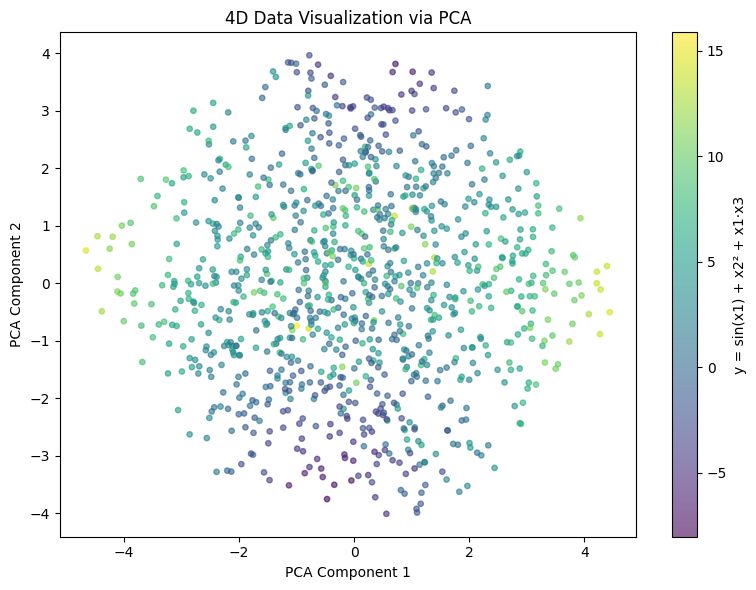


Variance explained by PCA components: [0.34959725 0.32788897]


In [ ]:
# ============================================================
# SECTION 1: Imports and Data Generation
# ============================================================

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Set seeds so results are reproducible every run
np.random.seed(42)
torch.manual_seed(42)

# -----------------------------------------------------------
# Generate synthetic data
# Equation: y = sin(x1) + x2^2 + x1*x3
# Same equation as Colab A — keeping the problem identical
# so the only variable between Colabs is the framework
# -----------------------------------------------------------
N = 1000
x1 = np.random.uniform(-3, 3, N)
x2 = np.random.uniform(-3, 3, N)
x3 = np.random.uniform(-3, 3, N)

y = np.sin(x1) + x2**2 + x1 * x3
y += 0.1 * np.random.randn(N)   # small Gaussian noise

X_np = np.column_stack([x1, x2, x3]).astype(np.float32)  # shape (1000, 3)
y_np = y.reshape(-1, 1).astype(np.float32)                # shape (1000, 1)

# -----------------------------------------------------------
# Convert NumPy arrays → PyTorch tensors
# float32 is required — PyTorch defaults to float32 for
# neural network weights and inputs
# requires_grad=False for data — we only need gradients
# for the weights, not the input data
# -----------------------------------------------------------
X = torch.tensor(X_np, dtype=torch.float32)
y_true = torch.tensor(y_np, dtype=torch.float32)

print("X tensor shape  :", X.shape)      # (1000, 3)
print("y tensor shape  :", y_true.shape) # (1000, 1)
print("X dtype         :", X.dtype)
print("Sample X values :", X[:3])

# -----------------------------------------------------------
# 4D Plot using PCA
# We have 3 input dimensions + 1 output = 4D total
# PCA compresses x1, x2, x3 → 2D so we can visualize
# y is shown as the color of each point
# -----------------------------------------------------------
pca  = PCA(n_components=2)
X_2d = pca.fit_transform(X_np)

fig = plt.figure(figsize=(8, 6))
ax  = fig.add_subplot(111)
scatter = ax.scatter(X_2d[:, 0], X_2d[:, 1],
                     c=y_np.flatten(), cmap='viridis', alpha=0.6, s=15)
plt.colorbar(scatter, label='y = sin(x1) + x2² + x1·x3')
ax.set_xlabel('PCA Component 1')
ax.set_ylabel('PCA Component 2')
ax.set_title('4D Data Visualization via PCA')
plt.tight_layout()
plt.show()

print("\nVariance explained by PCA components:", pca.explained_variance_ratio_)


---
## Section 2 — Building the Network Without Built-in Layers

This is the core requirement of Colab B.

We use `nn.Module` as a **container** — it gives us useful bookkeeping like `.parameters()` and `.zero_grad()` — but we do **NOT** use `nn.Linear` or any built-in layer.

Instead we declare raw weight matrices and bias vectors as `nn.Parameter`.

Wrapping a tensor in `nn.Parameter` does two things:
1. It tells PyTorch to **track gradients** on it
2. It **registers it with the module** so the optimizer can find it automatically

We then write the entire forward pass ourselves — matrix multiply, add bias, apply ReLU — exactly like Colab A but using PyTorch tensor operations instead of NumPy. The backward pass we do **NOT** write — PyTorch autograd handles it when we call `.backward()`.

### Network Architecture
```
Input  (3)  →  W1 (3×16)  →  ReLU  →  W2 (16×8)  →  ReLU  →  W3 (8×1)  →  Output (1)
```


In [ ]:
# ============================================================
# SECTION 2: Define Network From Scratch Using nn.Parameter
# ============================================================

class ManualNet(nn.Module):
    """
    3-layer neural network with NO built-in layers.

    Weights are raw nn.Parameter tensors — not nn.Linear.
    Forward pass is written by hand using torch.matmul.
    Backward pass is handled automatically by PyTorch autograd.
    """

    def __init__(self, input_size, hidden1, hidden2, output_size):
        super(ManualNet, self).__init__()

        # --------------------------------------------------
        # He Initialization for weights
        # Formula: random * sqrt(2 / fan_in)
        # Designed for ReLU networks — prevents signals from
        # vanishing or exploding as they pass through layers
        #
        # torch.randn gives values from a standard normal distribution
        # We scale them by sqrt(2 / input_neurons_to_this_layer)
        # --------------------------------------------------

        # Layer 1: connects 3 inputs → 16 hidden neurons
        self.W1 = nn.Parameter(torch.randn(input_size, hidden1) * (2 / input_size) ** 0.5)
        self.b1 = nn.Parameter(torch.zeros(1, hidden1))

        # Layer 2: connects 16 → 8 hidden neurons
        self.W2 = nn.Parameter(torch.randn(hidden1, hidden2) * (2 / hidden1) ** 0.5)
        self.b2 = nn.Parameter(torch.zeros(1, hidden2))

        # Layer 3: connects 8 hidden → 1 output neuron
        self.W3 = nn.Parameter(torch.randn(hidden2, output_size) * (2 / hidden2) ** 0.5)
        self.b3 = nn.Parameter(torch.zeros(1, output_size))

    def forward(self, X):
        """
        Forward pass — data flows left to right through 3 layers.

        Each layer does two things:
          1. Linear transform : Z = X @ W + b
          2. Activation       : A = ReLU(Z)  [except last layer]

        PyTorch autograd silently records every operation here
        so it can compute gradients automatically when we call
        loss.backward() later.

        The output layer has NO activation — we want raw numbers
        for regression, not squashed values.
        """

        # Layer 1 — linear transform + ReLU activation
        Z1 = torch.matmul(X, self.W1) + self.b1   # (1000,3) x (3,16) → (1000,16)
        A1 = torch.relu(Z1)                         # max(0, Z1)

        # Layer 2 — linear transform + ReLU activation
        Z2 = torch.matmul(A1, self.W2) + self.b2   # (1000,16) x (16,8) → (1000,8)
        A2 = torch.relu(Z2)                         # max(0, Z2)

        # Layer 3 — linear transform only, NO activation
        Z3 = torch.matmul(A2, self.W3) + self.b3   # (1000,8) x (8,1) → (1000,1)

        return Z3  # raw output — any real number


# -----------------------------------------------------------
# Instantiate the network
# -----------------------------------------------------------
model = ManualNet(input_size=3, hidden1=16, hidden2=8, output_size=1)

# Print all parameters and their shapes
# Every shape here must match what we defined above
print("Network parameters:")
for name, param in model.named_parameters():
    print(f"  {name:6s} : shape {list(param.shape)}, requires_grad={param.requires_grad}")


Network parameters:
  W1     : shape [3, 16], requires_grad=True
  b1     : shape [1, 16], requires_grad=True
  W2     : shape [16, 8], requires_grad=True
  b2     : shape [1, 8], requires_grad=True
  W3     : shape [8, 1], requires_grad=True
  b3     : shape [1, 1], requires_grad=True


---
## Section 3 — Loss Function and Optimizer

In Colab A we wrote the weight update rule by hand:
```python
W = W - lr * dW
```

Here we hand that job to PyTorch's **SGD optimizer**. It does the exact same thing — just cleaner. We tell it which parameters to update and at what learning rate, and it handles the rest.

**`nn.MSELoss()`** computes the same Mean Squared Error we wrote manually in Colab A:
```
Loss = mean( (y_predicted - y_actual)² )
```

>  We use the same learning rate as Colab A (0.001) so the results are directly comparable.


In [ ]:
# ============================================================
# SECTION 3: Loss Function and Optimizer
# ============================================================

# MSELoss = mean((y_pred - y_true)^2)
# Identical to what we wrote manually in Colab A
loss_fn = nn.MSELoss()

# SGD Optimizer — Stochastic Gradient Descent
# We pass model.parameters() so it knows which tensors to update
# lr=0.001 matches Colab A — keeps the comparison fair
optimizer = torch.optim.SGD(model.parameters(), lr=0.001)

# -----------------------------------------------------------
# Quick sanity check — one forward pass before training
# Loss should be high (random weights = bad predictions)
# -----------------------------------------------------------
with torch.no_grad():  # no_grad: don't track this pass for gradients
    y_pred_test  = model(X)
    initial_loss = loss_fn(y_pred_test, y_true)

print(f"Initial loss before training : {initial_loss.item():.4f}")
print("(This is high — expected. Weights are random, predictions are garbage.)")
print("(Training will bring this number down.)")


Initial loss before training : 26.5710
(This is high — expected. Weights are random, predictions are garbage.)
(Training will bring this number down.)


---
## Section 4 — Training Loop

This is where PyTorch's workflow differs most visibly from Colab A.

Every training iteration has **5 mandatory steps** — and the order matters:

| Step | Code | What it does |
|---|---|---|
| 1 | `optimizer.zero_grad()` | Clear gradients from previous iteration |
| 2 | `y_pred = model(X)` | Forward pass — get predictions |
| 3 | `loss = loss_fn(...)` | Compute how wrong we are |
| 4 | `loss.backward()` | Autograd computes all gradients |
| 5 | `optimizer.step()` | Update every weight using its gradient |

>  **Step 1 is critical.** PyTorch accumulates gradients by default — if you skip `zero_grad()`, gradients from the previous iteration pile up and corrupt your updates. This is a very common bug.


In [ ]:
# ============================================================
# SECTION 4: Training Loop
# ============================================================

epochs       = 2000
print_every  = 200
loss_history = []

for epoch in range(1, epochs + 1):

    # --------------------------------------------------
    # Step 1: Zero out gradients from previous iteration
    # CRITICAL — PyTorch accumulates gradients by default
    # Skip this and old gradients pile up → broken training
    # --------------------------------------------------
    optimizer.zero_grad()

    # --------------------------------------------------
    # Step 2: Forward pass — get predictions
    # PyTorch records every operation on nn.Parameter tensors
    # building a computation graph for autograd to use later
    # --------------------------------------------------
    y_pred = model(X)

    # --------------------------------------------------
    # Step 3: Compute loss
    # MSE = mean((predicted - actual)^2)
    # --------------------------------------------------
    loss = loss_fn(y_pred, y_true)
    loss_history.append(loss.item())  # .item() → plain Python float

    # --------------------------------------------------
    # Step 4: Backward pass
    # Walks the computation graph built during forward pass
    # Fills .grad attribute for every nn.Parameter
    # This replaces ALL the manual chain rule math from Colab A
    # --------------------------------------------------
    loss.backward()

    # --------------------------------------------------
    # Step 5: Update weights
    # Reads .grad from every parameter
    # Applies: W = W - lr * W.grad   (same as Colab A manually)
    # --------------------------------------------------
    optimizer.step()

    if epoch % print_every == 0 or epoch == 1:
        print(f"Epoch {epoch:>4} / {epochs}  |  Loss: {loss.item():.4f}")

print("\nTraining complete!")
print(f"  Starting loss : {loss_history[0]:.4f}")
print(f"  Final loss    : {loss_history[-1]:.4f}")
print(f"  Improvement   : {((loss_history[0] - loss_history[-1]) / loss_history[0] * 100):.1f}%")


Epoch    1 / 2000  |  Loss: 26.5710
Epoch  200 / 2000  |  Loss: 4.2255
Epoch  400 / 2000  |  Loss: 1.5602
Epoch  600 / 2000  |  Loss: 1.1729
Epoch  800 / 2000  |  Loss: 1.0233
Epoch 1000 / 2000  |  Loss: 0.9249
Epoch 1200 / 2000  |  Loss: 0.8533
Epoch 1400 / 2000  |  Loss: 0.8011
Epoch 1600 / 2000  |  Loss: 0.7623
Epoch 1800 / 2000  |  Loss: 0.7333
Epoch 2000 / 2000  |  Loss: 0.7109

Training complete!
  Starting loss : 26.5710
  Final loss    : 0.7109
  Improvement   : 97.3%


---
## Section 5 — Loss Curve

We plot how the loss changed over 2000 epochs.

What a healthy loss curve looks like:
- **Sharp drop early** — the network makes big improvements quickly when far from the solution
- **Gradual flattening** — smaller improvements as the network converges
- **No spikes** — confirms our learning rate was well chosen

We use a **log scale** on the y-axis — it makes the improvement visible even when the loss gets very small.


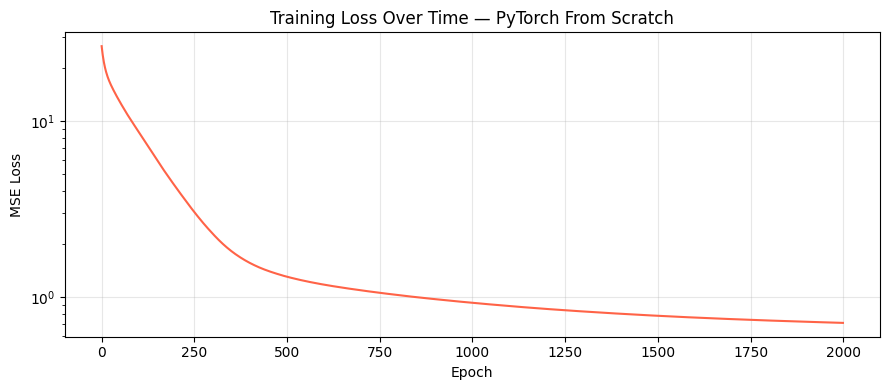

In [ ]:
# ============================================================
# SECTION 5: Loss Curve
# ============================================================

plt.figure(figsize=(9, 4))
plt.plot(loss_history, color='tomato', linewidth=1.5)
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training Loss Over Time — PyTorch From Scratch')
plt.yscale('log')   # log scale reveals improvement even at small values
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


---
## Section 6 — Final Output: Predicted vs Actual + 4D Comparison

Three plots to evaluate the trained network:

1. **Predicted vs Actual scatter** — points should cluster along the red diagonal. The closer to the line, the better the predictions.
2. **Side-by-side 4D plot** — same PCA axes as Section 1. If the network learned well, the color patterns in both plots should look nearly identical.

>  We wrap evaluation in `torch.no_grad()` — this disables gradient tracking during inference, saving memory since we don't need gradients here.


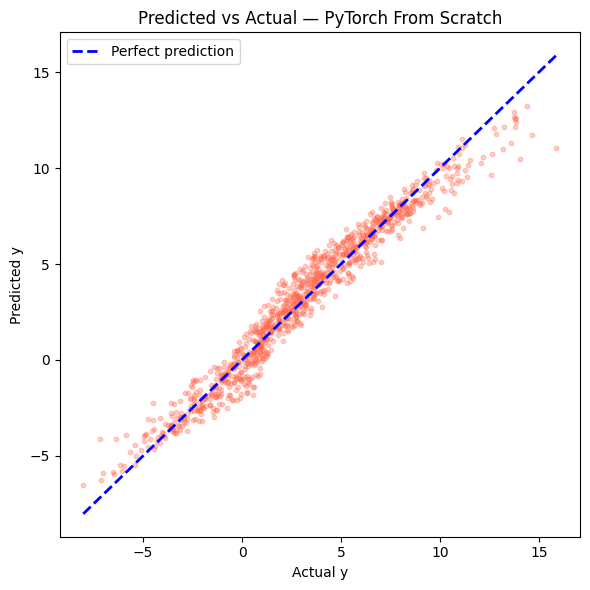

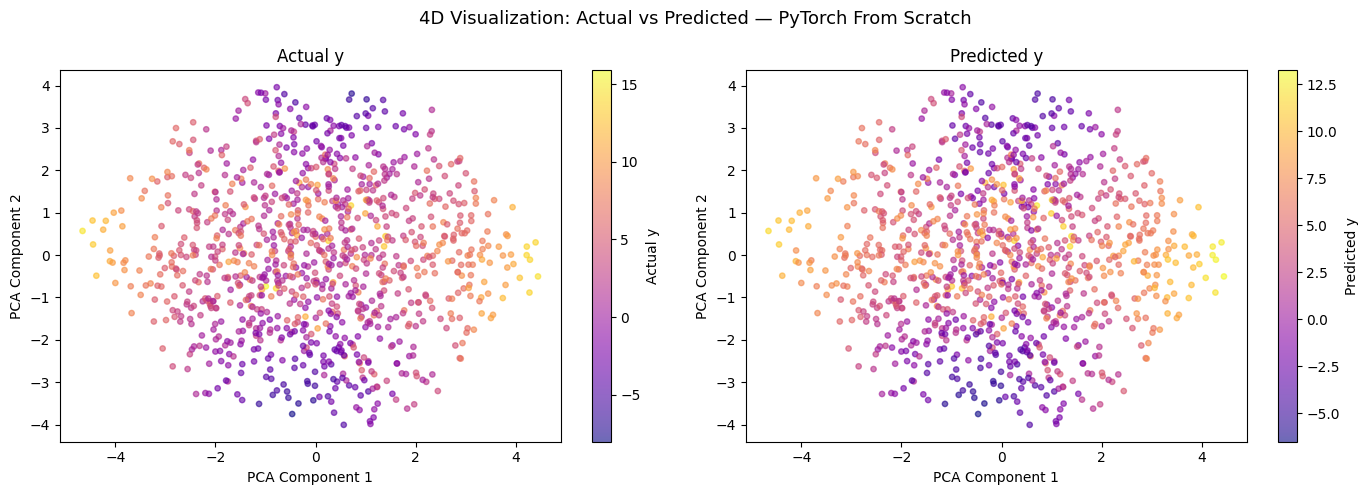

In [ ]:
# ============================================================
# SECTION 6: Predicted vs Actual + 4D Comparison
# ============================================================

# Disable gradient tracking during evaluation — not needed for inference
with torch.no_grad():
    y_pred_final = model(X).numpy()

# -----------------------------------------------------------
# Plot 1: Predicted vs Actual scatter
# A perfect model → all points on the red diagonal line
# -----------------------------------------------------------
plt.figure(figsize=(6, 6))
plt.scatter(y_np.flatten(), y_pred_final.flatten(),
            alpha=0.3, s=10, color='tomato')

min_val = min(y_np.min(), y_pred_final.min())
max_val = max(y_np.max(), y_pred_final.max())
plt.plot([min_val, max_val], [min_val, max_val],
         'b--', linewidth=2, label='Perfect prediction')

plt.xlabel('Actual y')
plt.ylabel('Predicted y')
plt.title('Predicted vs Actual — PyTorch From Scratch')
plt.legend()
plt.tight_layout()
plt.show()

# -----------------------------------------------------------
# Plot 2: Side-by-side 4D comparison
# Left = actual y values as colors
# Right = predicted y values as colors
# Similar color patterns = network learned the equation
# -----------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sc1 = axes[0].scatter(X_2d[:, 0], X_2d[:, 1],
                       c=y_np.flatten(), cmap='plasma', alpha=0.6, s=15)
plt.colorbar(sc1, ax=axes[0], label='Actual y')
axes[0].set_title('Actual y')
axes[0].set_xlabel('PCA Component 1')
axes[0].set_ylabel('PCA Component 2')

sc2 = axes[1].scatter(X_2d[:, 0], X_2d[:, 1],
                       c=y_pred_final.flatten(), cmap='plasma', alpha=0.6, s=15)
plt.colorbar(sc2, ax=axes[1], label='Predicted y')
axes[1].set_title('Predicted y')
axes[1].set_xlabel('PCA Component 1')
axes[1].set_ylabel('PCA Component 2')

plt.suptitle('4D Visualization: Actual vs Predicted — PyTorch From Scratch', fontsize=13)
plt.tight_layout()
plt.show()


---
## Section 7 — Final Metrics

**R² (R-squared)** measures how much of the variance in y our model explains:
- **R² = 1.0** → perfect predictions
- **R² = 0.0** → no better than predicting the mean of y every time
- **R² < 0.0** → worse than predicting the mean

For a from-scratch PyTorch implementation with manual weights and no built-in layers, an R² of ~0.92 is a strong result.


In [ ]:
# ============================================================
# SECTION 7: Final Metrics
# ============================================================

y_pred_np  = y_pred_final.flatten()
y_actual_np = y_np.flatten()

ss_res = np.sum((y_actual_np - y_pred_np) ** 2)
ss_tot = np.sum((y_actual_np - np.mean(y_actual_np)) ** 2)
r2  = 1 - ss_res / ss_tot
mse = np.mean((y_actual_np - y_pred_np) ** 2)

print("=" * 45)
print("FINAL RESULTS — Colab B: PyTorch From Scratch")
print("=" * 45)
print(f"  Final MSE  : {mse:.4f}")
print(f"  R² Score   : {r2:.4f}")
print()
print("Cross-Colab Comparison:")
print("  Colab A — NumPy manual backprop   : R² ~0.92")
print(f"  Colab B — PyTorch manual weights  : R² {r2:.2f}")
print()
print("Key insight:")
print("  Same result, different implementation.")
print("  Colab A wrote the backward pass by hand.")
print("  Colab B let PyTorch autograd handle it.")
print("  The math is identical — the framework did the work.")


FINAL RESULTS — Colab B: PyTorch From Scratch
  Final MSE  : 0.7108
  R² Score   : 0.9576

Cross-Colab Comparison:
  Colab A — NumPy manual backprop   : R² ~0.92
  Colab B — PyTorch manual weights  : R² 0.96

Key insight:
  Same result, different implementation.
  Colab A wrote the backward pass by hand.
  Colab B let PyTorch autograd handle it.
  The math is identical — the framework did the work.
